In [25]:
import seaborn as sns
import pandas as pd
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

df = pd.read_pickle(
    "/home/clement/Documents/Projets/OcularRigidity/manuscript/chapters/analysis/structural_pulsation/positional_pulsation/structural_pulsation_df.pkl"
)

replace_dict = {"CZMI237206055": "C", "2139559": "E", "1097814": "N"}
df["pID"] = df["pID"].replace(replace_dict)


In [ ]:
input_C = Path()

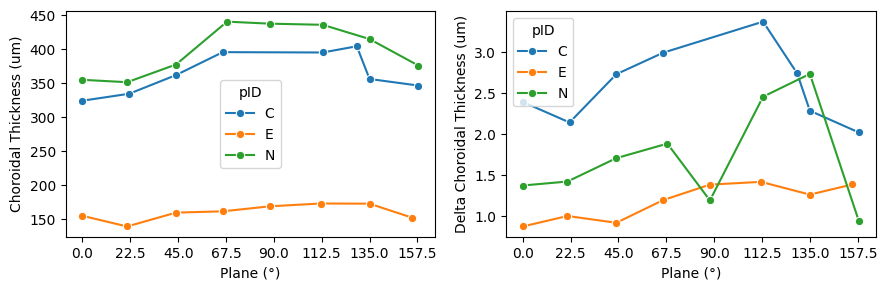

In [24]:
# | label: fig-angular-choroidal-thickness
# | fig-cap: "Choroidal thickness and pulsatile Δ thickness across 8 different acquisition planes."
# | warning: false
# | echo: false

plotted_df = df[df["Type"].notna()].copy()

panels = [
    ("minCT_um", "Choroidal Thickness (um)"),
    ("deltaCT_um", "Delta Choroidal Thickness (um)"),
]
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(panels),
    sharex=True,
    figsize=(9, 3),
)
x = plotted_df["Type"].to_numpy(dtype=float)
step = np.min(np.diff(np.sort(x)))

for col, (key, label) in enumerate(panels):
    ax = axes[col]
    sns.lineplot(
        data=plotted_df, x="Type", y=key, hue="pID", ax=ax, legend=True, marker="o"
    )
    ax.set_xlabel("Plane (°)")
    ax.set_ylabel(label)
    ax.set_xticks(x)

    # Set the x ticks to multiples of 22.5 degrees
    ax.set_xticks(np.arange(0, 180, 22.5))

fig.canvas.draw()  # final axes size, to size the thumbnails


plt.tight_layout()
plt.show()
